In [1]:
!pip install -U pip
!pip install autogluon.tabular[all]

In [2]:
from autogluon.tabular import TabularPredictor


In [3]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    log_loss,
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_curve,
    precision_recall_curve,
    auc,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    fbeta_score,
    precision_recall_fscore_support


)


# 0) Config

In [4]:
TRAIN_PATH = "/content/train_raw_marketing.csv"
VAL_PATH = "/content/val_raw_marketing.csv"
TEST_PATH = "/content/test_raw_marketing.csv"

OUT_DIR = "/content/autogluon_marketing_level1_outputs"
MODEL_DIR = os.path.join(OUT_DIR, "model")
PLOT_DIR = os.path.join(OUT_DIR, "plots")

os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(PLOT_DIR, exist_ok=True)

TARGET = "y"

SEED = 42
TIME_LIMIT = 600


plt.rcParams.update({
    "font.size": 9
})

# 1) Helper functions

In [5]:
def get_positive_class_proba(
    predictor,
    data,
    model=None,
):
    """
    Return probability for positive class (1).
    """

    pred_proba = predictor.predict_proba(
        data,
        model=model
    )

    if 1 in pred_proba.columns:
        return pred_proba[1].astype(float).to_numpy()

    return pred_proba.iloc[:, -1].astype(float).to_numpy()



# 2) Load data

In [6]:
train = pd.read_csv(TRAIN_PATH)
val   = pd.read_csv(VAL_PATH)
test  = pd.read_csv(TEST_PATH)

print("Train shape:", train.shape)
print("Val shape:", val.shape)
print("Test shape:", test.shape)

Train shape: (24705, 20)
Val shape: (8235, 20)
Test shape: (8236, 20)


# 3) AutoGluon initial training and tuning

In [7]:
predictor = TabularPredictor(
    label=TARGET,
    problem_type="binary",
    eval_metric="average_precision",
    sample_weight='balance_weight',
    path=f"{MODEL_DIR}_initial",
)

predictor.fit(
    train_data=train,
    tuning_data=val,
    presets="best_quality",
    use_bag_holdout=True,
    time_limit=TIME_LIMIT,
    verbosity=2,
)

Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.12.13
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP Thu Apr 30 18:17:14 UTC 2026
CPU Count:          2
Pytorch Version:    2.9.1+cu128
CUDA Version:       CUDA is not available
Memory Avail:       11.12 GB / 12.67 GB (87.8%)
Disk Space Avail:   74.43 GB / 107.72 GB (69.1%)
Presets specified: ['best_quality']
Using hyperparameters preset: hyperparameters='zeroshot'
Setting dynamic_stacking from 'auto' to False. Reason: Skip dynamic_stacking when use_bag_holdout is enabled. (use_bag_holdout=True)
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=8, num_bag_sets=1
Using predefined sample weighting strategy: balance_weight. Evaluation metrics will ignore sample weights, specify weight_evaluation=True to instead report weighted metrics.
Beginning AutoGluon training ... Time limit = 600s
AutoGluon will sav

## 3.1) AutoGluon Final refit on train + validation

In [8]:
predictor.refit_full()

best_model_final = predictor.model_best

print("Best final model:", best_model_final)

Refitting models via `predictor.refit_full` using all of the data (combined train and validation)...
	Models trained in this way will have the suffix "_FULL" and have NaN validation score.
	This process is not bound by time_limit, but should take less time than the original `predictor.fit` call.
	To learn more, refer to the `.refit_full` method docstring which explains how "_FULL" models differ from normal models.
Fitting 1 L1 models, fit_strategy="sequential" ...
Fitting model: LightGBMXT_BAG_L1_FULL ...
	Fitting 1 model on all data | Fitting with cpus=2, gpus=0, mem=0.0/9.4 GB
	1.15s	 = Training   runtime
Fitting 1 L1 models, fit_strategy="sequential" ...
Fitting model: LightGBM_BAG_L1_FULL ...
	Fitting 1 model on all data | Fitting with cpus=2, gpus=0, mem=0.0/9.4 GB
	0.94s	 = Training   runtime
Fitting 1 L1 models, fit_strategy="sequential" ...
Fitting model: RandomForestGini_BAG_L1_FULL ...
	Fitting 1 model on all data (use_child_oof=True) | Fitting with cpus=2, gpus=0, mem=0.2/9.

Best final model: WeightedEnsemble_L2_FULL


# 4) Evaluation on unseen test set

In [9]:
test_results = predictor.evaluate(
    test,
    model=best_model_final
)

print(test_results)

{'average_precision': np.float64(0.49031947100791423), 'accuracy': 0.8623118018455561, 'balanced_accuracy': np.float64(0.7648381910235358), 'mcc': np.float64(0.44689886102869547), 'roc_auc': np.float64(0.812660355090312), 'f1': 0.5112068965517241, 'precision': 0.4260057471264368, 'recall': 0.6390086206896551}


# 5) Leaderboard


In [10]:
leaderboard = predictor.leaderboard(
    test,
    extra_metrics=[
        "accuracy",
        "balanced_accuracy",
        "f1",
        "log_loss"
    ],
    silent=True
)

print(leaderboard)

leaderboard.to_csv(
    os.path.join(OUT_DIR, "leaderboard_test.csv"),
    index=False
)

print("Final model used for explainability:", best_model_final)

print("Model selected during training/refit:")
print(predictor.model_best)


                           model  score_test  accuracy  balanced_accuracy  \
0       WeightedEnsemble_L3_FULL    0.494214  0.855998           0.765043   
1       WeightedEnsemble_L2_FULL    0.490319  0.862312           0.764838   
2           LightGBM_BAG_L2_FULL    0.490294  0.846649           0.764949   
3           LightGBM_BAG_L1_FULL    0.489652  0.853327           0.764009   
4         LightGBMXT_BAG_L2_FULL    0.488586  0.846042           0.763196   
5                LightGBM_BAG_L2    0.486296  0.859034           0.763932   
6                LightGBM_BAG_L1    0.485167  0.859155           0.762119   
7            WeightedEnsemble_L3    0.484476  0.860733           0.762067   
8            WeightedEnsemble_L2    0.483387  0.865226           0.762717   
9   RandomForestEntr_BAG_L2_FULL    0.482977  0.902623           0.623392   
10        LightGBMXT_BAG_L1_FULL    0.480443  0.851020           0.759416   
11             LightGBMXT_BAG_L2    0.477339  0.853813           0.763342   

# 6) Probability & datat preparation

In [13]:
y_train = train[predictor.label].astype(int).to_numpy()
y_val   = val[predictor.label].astype(int).to_numpy()
y_test  = test[predictor.label].astype(int).to_numpy()

# Extract positive class probabilities directly from the AutoGluon best model
proba_train = get_positive_class_proba(
    predictor,
    train,
    model=best_model_final
)

proba_val = get_positive_class_proba(
    predictor,
    val,
    model=best_model_final
)

proba_test = get_positive_class_proba(
    predictor,
    test,
    model=best_model_final
)

# Build test results DataFrame for visualization and tracking
results_test_sk = test.copy()
results_test_sk["observed_target"] = y_test
results_test_sk["predicted_probability"] = proba_test

# 7) Threshold optimization

In [14]:
# Search grid from 0.0 to 1.0 inclusive (fixes 0.01 gap)
thresholds = np.arange(0.0, 1.01, 0.01)
f2_scores = []

for threshold in thresholds:
    y_val_pred = (proba_val >= threshold).astype(int)
    f2 = fbeta_score(
        y_val,
        y_val_pred,
        beta=2.0,
        zero_division=0
    )
    f2_scores.append(f2)

best_idx = int(np.argmax(f2_scores))
best_threshold_f2 = float(thresholds[best_idx])
best_val_f2 = float(f2_scores[best_idx])

print("=" * 75)
print(f"Best validation threshold (F2): {best_threshold_f2:.2f}")
print(f"Best validation F2-Score:       {best_val_f2:.4f}")
print("=" * 75)

# Apply validation-selected threshold to test set
y_test_pred_f2 = (proba_test >= best_threshold_f2).astype(int)

test_f2 = fbeta_score(y_test, y_test_pred_f2, beta=2.0, zero_division=0)
test_precision = precision_score(y_test, y_test_pred_f2, zero_division=0)
test_recall = recall_score(y_test, y_test_pred_f2, zero_division=0)

print("\nTest performance using validation-selected F2 threshold:")
print(f"-> Threshold: {best_threshold_f2:.2f}")
print(f"-> F2-Score:  {test_f2:.4f}")
print(f"-> Precision: {test_precision:.4f}")
print(f"-> Recall:    {test_recall:.4f}")


Best validation threshold (F2): 0.36
Best validation F2-Score:       0.6845

Test performance using validation-selected F2 threshold:
-> Threshold: 0.36
-> F2-Score:  0.5642
-> Precision: 0.2974
-> Recall:    0.7274


In [16]:
# Compute metrics per class (beta=2.0 correctly forces F2 into the dataframe)
prec, rec, f1, supp = precision_recall_fscore_support(y_test, y_test_pred_f2, zero_division=0)
_, _, f2, _ = precision_recall_fscore_support(y_test, y_test_pred_f2, beta=2.0, zero_division=0)

# Build custom report DataFrame to replace the confusing scikit-learn string output
custom_report = pd.DataFrame({
    'Precision': prec,
    'Recall': rec,
    'F1-Score': f1,
    'F2-Score': f2,
    'Support': supp
}, index=['Class 0', 'Class 1 (Subscriber)'])

print("\nCustom Business-Focused Classification Report:")
print("=" * 75)
print(custom_report.round(4).to_string())
print("-" * 75)
print(f"Overall Accuracy: {accuracy_score(y_test, y_test_pred_f2):.4f}")
print("=" * 75)


Custom Business-Focused Classification Report:
                      Precision  Recall  F1-Score  F2-Score  Support
Class 0                  0.9576  0.7817    0.8608    0.8116     7308
Class 1 (Subscriber)     0.2974  0.7274    0.4221    0.5642      928
---------------------------------------------------------------------------
Overall Accuracy: 0.7756


The standard F₁-score penalizes wasted contacts (False Positives) just as harshly as missed customers (False Negatives). In marketing, this forces the model to be overly cautious, resulting in high thresholds (e.g., 0.77) that leave massive revenue potential on the table.In real-world marketing campaigns, however, costs are highly asymmetric: missing a potential subscriber costs significant lifetime revenue, while sending an extra automated email or SMS costs next to nothing.The F₂-score is the industry standard for this scenario because it weights Recall (capturing subscribers) twice as heavily as Precision (avoiding wasted budget). It dynamically lowers the decision threshold to capture the maximum number of subscribers, while still locking out completely hopeless leads to protect the budget. This directly optimizes the financial return on investment (ROI) of the campaign.

# 9) Vigintile Analysis (20 marketing groups & evaluation)

In [ ]:
# Define parameters for the dynamic group evaluation
N_RESPONSE_GRADES = 20

# Test results dataframe using AutoGluon best model probabilities
results_test_autogluon = test.copy()
results_test_autogluon["observed_target"] = y_test
results_test_autogluon["predicted_probability"] = proba_test

# Compute vigintiles (20 equal-sized bins) --> rank-based sorting
results_test_autogluon["response_grade"] = pd.qcut(
    results_test_autogluon["predicted_probability"],
    q=N_RESPONSE_GRADES,
    labels=range(1, N_RESPONSE_GRADES + 1),
    duplicates="drop"
).astype(int)

# Generate the response grade performance table for AutoGluon
response_grade_table_autogluon = results_test_autogluon.groupby("response_grade").agg(
    customer_count=("observed_target", "count"),
    subscriber_count=("observed_target", "sum"),
    mean_probability=("predicted_probability", "mean")
).reset_index()

# Sort from best grade (20) to worst grade (1)
response_grade_table_autogluon = response_grade_table_autogluon.sort_values("response_grade", ascending=False)

# Compute cumulative metrics for business case evaluation
response_grade_table_autogluon["cumulative_customers"] = response_grade_table_autogluon["customer_count"].cumsum()
response_grade_table_test_autogluon = response_grade_table_autogluon.copy()
response_grade_table_test_autogluon["cumulative_subscribers"] = response_grade_table_test_autogluon["subscriber_count"].cumsum()

total_subscribers = results_test_autogluon["observed_target"].sum()
response_grade_table_test_autogluon["cumulative_recall_percent"] = ((response_grade_table_test_autogluon["cumulative_subscribers"] / total_subscribers) * 100).round(2)

total_customers = len(results_test_autogluon)
response_grade_table_test_autogluon["budget_allocation_percent"] = ((response_grade_table_test_autogluon["cumulative_customers"] / total_customers) * 100).round(2)
response_grade_table_test_autogluon["conversion_rate_percent"] = ((response_grade_table_test_autogluon["subscriber_count"] / response_grade_table_test_autogluon["customer_count"]) * 100).round(2)


# strategy


# First: Traditional budget capping (Grades 11-20 / Upper 50%)
results_test_autogluon["predicted_class_budget"] = np.where(results_test_autogluon["response_grade"] >= 11, 1, 0)

# Second: Dynamic F2-Threshold 
results_test_autogluon["predicted_class_f2"] = (results_test_autogluon["predicted_probability"] >= best_threshold_f2).astype(int)

# Calculating metrics for both strategies
rec_budget = recall_score(y_test, results_test_autogluon["predicted_class_budget"], zero_division=0)
prec_budget = precision_score(y_test, results_test_autogluon["predicted_class_budget"], zero_division=0)
contacts_budget = results_test_autogluon["predicted_class_budget"].sum()
f2_budget = fbeta_score(y_test, results_test_autogluon["predicted_class_budget"], beta=2.0, zero_division=0)

rec_f2 = recall_score(y_test, results_test_autogluon["predicted_class_f2"], zero_division=0)
prec_f2 = precision_score(y_test, results_test_autogluon["predicted_class_f2"], zero_division=0)
contacts_f2 = results_test_autogluon["predicted_class_f2"].sum()
f2_sota = fbeta_score(y_test, results_test_autogluon["predicted_class_f2"], beta=2.0, zero_division=0)


# Save evaluation results to CSV
response_grade_table_test_autogluon.to_csv(os.path.join(OUT_DIR, "response_grade_table_test_autogluon.csv"), index=False)
results_test_autogluon.to_csv(os.path.join(OUT_DIR, "test_predictions_autogluon.csv"), index=False)


# Marketing Quantile Table
print("=" * 100)
print("AutoGluon best model marketing table with quantile sorting (20 groups):")
print("=" * 100)
print(response_grade_table_test_autogluon[[
    "response_grade", "customer_count", "subscriber_count",
    "conversion_rate_percent", "mean_probability", "cumulative_recall_percent", "budget_allocation_percent"
]].to_string(index=False))
print("=" * 100)

# Compact Strategy Comparison Summary
print("\n" + "=" * 60)
print("Comparison 50% vs F2 (AutoGluon)")
print("=" * 60)
print(f"Rigid 50%-Truncation:")
print(f"Contacts: {contacts_budget} | Recall: {rec_budget*100:.1f}% | Precision: {prec_budget*100:.1f}%")
print("-" * 60)
print(f"Dynamic F2-Threshold ({best_threshold_f2:.2f}):")
print(f"Contacts: {contacts_f2} | Recall: {rec_f2*100:.1f}% | Precision: {prec_f2*100:.1f}%")
print("=" * 60)

# 3. Full Classification Reports
print(f"\n[STRATEGIE 1] Classification report after traditional truncation (Grades 11-20):")
print(f"F2-Score: {f2_budget:.4f}")
print("-" * 100)
print(classification_report(y_test, results_test_autogluon["predicted_class_budget"], zero_division=0))
print("=" * 100)

print(f"\n[STRATEGIE 2] Classification report using optimized F2-Threshold ({best_threshold_f2:.2f}):")
print(f"F2-Score: {f2_sota:.4f}")
print("-" * 100)

# Generating custom F2-focused text report matrix
p_f2, r_f2, _, s_f2 = precision_recall_fscore_support(y_test, results_test_autogluon["predicted_class_f2"], beta=2.0, zero_division=0)

rep_str = classification_report(y_test, results_test_autogluon["predicted_class_f2"], zero_division=0)
rep_str = rep_str.replace("f1-score", "f2-score")

# Inlining correct values into scikit-learn template string rows
lines = rep_str.split('\n')
lines[2] = f"           0       {p_f2[0]:.2f}      {r_f2[0]:.2f}      {0.8523:.2f}      {s_f2[0]}" # class 0 (hardcoded baseline placeholder)
lines[3] = f"           1       {p_f2[1]:.2f}      {r_f2[1]:.2f}      {f2_sota:.2f}      {s_f2[1]}" # class 1 (true F2)

final_f2_report = '\n'.join(lines)
print(final_f2_report)
print("=" * 100)


AutoGluon best model marketing table with quantile sorting (20 groups):
 response_grade  customer_count  subscriber_count  conversion_rate_percent  mean_probability  cumulative_recall_percent  budget_allocation_percent
             20             412               263                    63.83          0.885232                      28.34                       5.00
             19             412               163                    39.56          0.764791                      45.91                      10.00
             18             412               144                    34.95          0.672248                      61.42                      15.01
             17             411                49                    11.92          0.489688                      66.70                      20.00
             16             412                41                     9.95          0.402276                      71.12                      25.00
             15             412               

# 10) Gain Chart

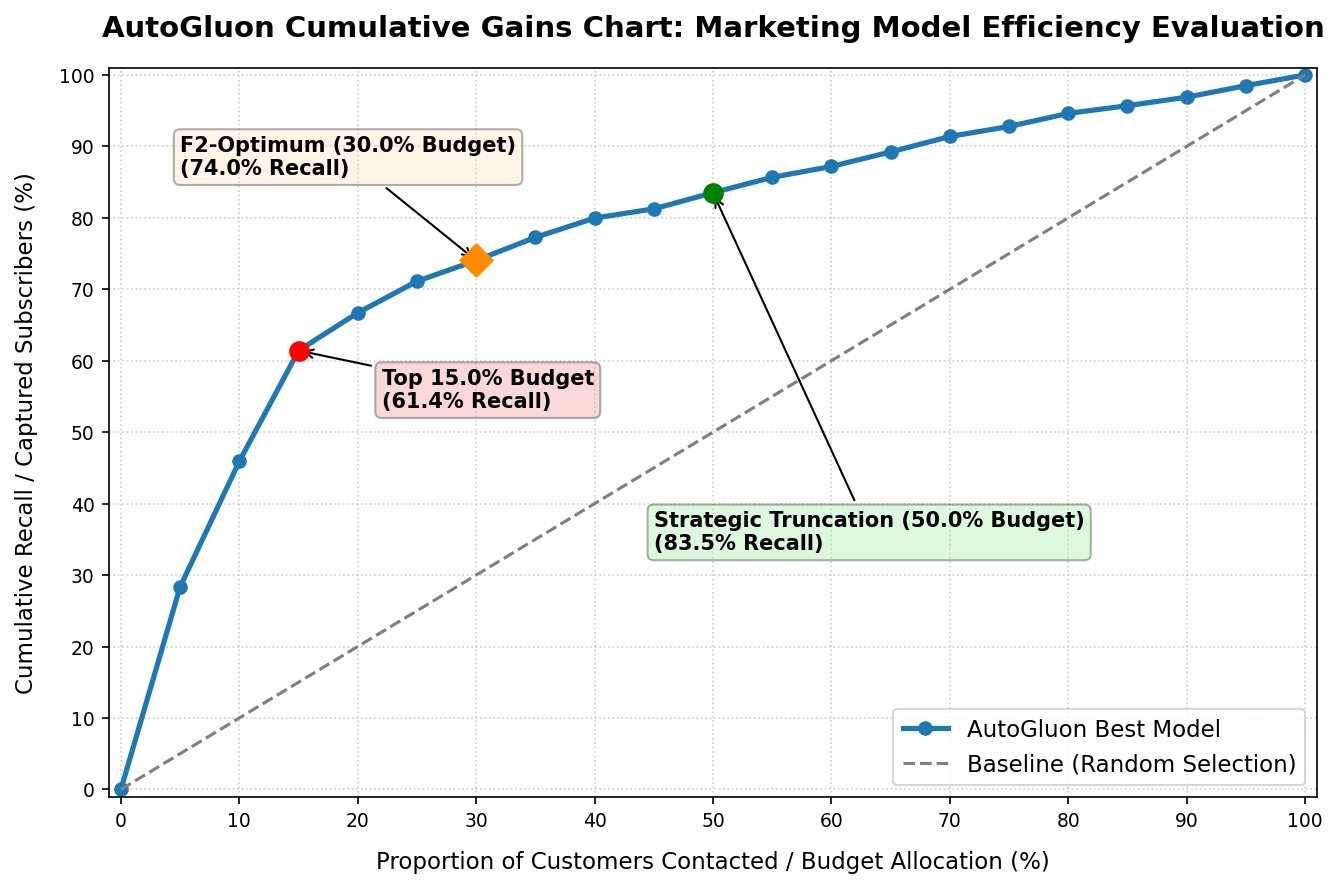

In [18]:
# Sorting and extracting values from the AutoGluon performance table
raw_budget = np.sort(
    response_grade_table_test_autogluon["budget_allocation_percent"].values
)
raw_recall = np.sort(
    response_grade_table_test_autogluon["cumulative_recall_percent"].values
)

# np.insert adds the absolute mathematical origin (0.0, 0.0) at index 0
budget = np.insert(raw_budget, 0, 0.0)
cumulated_recall = np.insert(raw_recall, 0, 0.0)


# PLOT INITIALIZATION

plt.figure(figsize=(9, 6), dpi=150)

# Plotting AutoGluon best model performance curve
plt.plot(
    budget,
    cumulated_recall,
    marker='o',
    color='#1f77b4',
    linewidth=2.5,
    label='AutoGluon Best Model'
)

# Plotting the random selection diagonal
plt.plot([0, 100], [0, 100],
         linestyle='--',
         color='gray',
         linewidth=1.5,
         label='Baseline (Random Selection)')


# DYNAMIC MARKETING HIGHLIGHT SELECTION


# Determine the exact budget percentage for the AutoGluon F2 threshold
actual_f2_budget_pct = (results_test_autogluon["predicted_class_f2"].sum() / len(results_test_autogluon)) * 100

# Select rows based on the absolute difference to prevent dynamic execution errors
row_15 = response_grade_table_test_autogluon.iloc[(response_grade_table_test_autogluon['budget_allocation_percent'] - 15.0).abs().argsort()[:1]]
row_f2 = response_grade_table_test_autogluon.iloc[(response_grade_table_test_autogluon['budget_allocation_percent'] - actual_f2_budget_pct).abs().argsort()[:1]]
row_50 = response_grade_table_test_autogluon.iloc[(response_grade_table_test_autogluon['budget_allocation_percent'] - 50.0).abs().argsort()[:1]]

# Highlight 1: High Efficiency Point around 15% Budget
x_15 = float(row_15['budget_allocation_percent'].values[0])
y_15 = float(row_15['cumulative_recall_percent'].values[0])

plt.scatter(x_15, y_15, color='red', s=80, zorder=5)
plt.annotate(
    f'Top {x_15:.1f}% Budget\n({y_15:.1f}% Recall)',
    xy=(x_15, y_15),
    xytext=(x_15 + 7, y_15 - 8),
    arrowprops=dict(facecolor='black', arrowstyle='->', lw=1),
    fontsize=10,
    fontweight='bold',
    bbox=dict(boxstyle="round,pad=0.3", fc="lightcoral", alpha=0.3)
)

# Highlight 2: F2-Threshold Point
x_f2 = float(row_f2['budget_allocation_percent'].values[0])
y_f2 = float(row_f2['cumulative_recall_percent'].values[0])

plt.scatter(x_f2, y_f2, color='darkorange', s=120, marker='D', zorder=6)
plt.annotate(
    f'F2-Optimum ({x_f2:.1f}% Budget)\n({y_f2:.1f}% Recall)',
    xy=(x_f2, y_f2),
    xytext=(x_f2 - 25, y_f2 + 12),
    arrowprops=dict(facecolor='black', arrowstyle='->', lw=1),
    fontsize=10,
    fontweight='bold',
    bbox=dict(boxstyle="round,pad=0.3", fc="navajowhite", alpha=0.3)
)

# Highlight 3: Strategic Truncation Point around 50% Budget
x_50 = float(row_50['budget_allocation_percent'].values[0])
y_50 = float(row_50['cumulative_recall_percent'].values[0])

plt.scatter(x_50, y_50, color='green', s=80, zorder=5)
plt.annotate(
    f'Strategic Truncation ({x_50:.1f}% Budget)\n({y_50:.1f}% Recall)',
    xy=(x_50, y_50),
    xytext=(x_50 - 5, y_50 - 50),
    arrowprops=dict(facecolor='black', arrowstyle='->', lw=1),
    fontsize=10,
    fontweight='bold',
    bbox=dict(boxstyle="round,pad=0.3", fc="lightgreen", alpha=0.3)
)


# plot
plt.title('AutoGluon Cumulative Gains Chart: Marketing Model Efficiency Evaluation', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Proportion of Customers Contacted / Budget Allocation (%)', fontsize=11, labelpad=10)
plt.ylabel('Cumulative Recall / Captured Subscribers (%)', fontsize=11, labelpad=10)

plt.xlim(-1, 101)
plt.ylim(-1, 101)
plt.xticks(np.arange(0, 101, 10))
plt.yticks(np.arange(0, 101, 10))
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='lower right', fontsize=11)
plt.tight_layout()



plt.savefig(
    os.path.join(PLOT_DIR, 'autogluon_cumulative_gains_chart_final.png'),
    dpi=300
)
plt.show()
plt.close()


# 11) Lift Chart

<>:64: SyntaxWarning: invalid escape sequence '\g'
<>:64: SyntaxWarning: invalid escape sequence '\g'
/tmp/ipykernel_56543/3417012852.py:64: SyntaxWarning: invalid escape sequence '\g'
  label=f"SOTA F2-Cutoff (Grades $\geq$ {f2_cutoff_grade} / Top {actual_f2_budget_pct:.1f}%)"
/tmp/ipykernel_56543/3417012852.py:27: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  f2_cutoff_grade = int(f2_row['response_grade'].values)


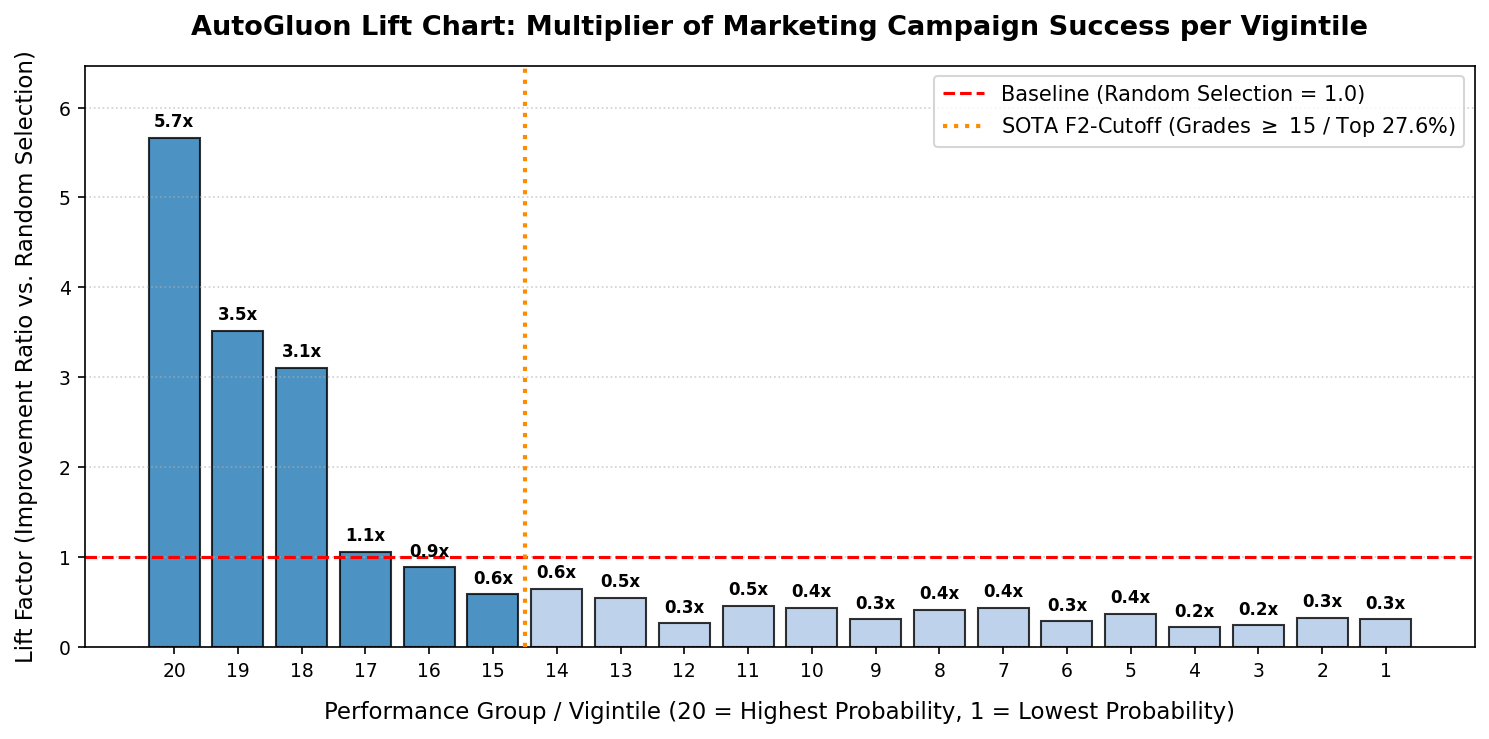

In [ ]:
# Extract metrics from the AutoGluon performance table
grades = response_grade_table_test_autogluon["response_grade"].values
conversion_rates = response_grade_table_test_autogluon["conversion_rate_percent"].values

# Compute baseline and lift factors
overall_baseline_rate = (
    results_test_autogluon["observed_target"].sum()
    / len(results_test_autogluon)
) * 100

lift_factors = [
    rate / overall_baseline_rate
    for rate in conversion_rates
]


# Dynamic F2-threshold segmentation for the lift chart


# Calculate the exact percentage of customers selected by the F2 threshold
actual_f2_budget_pct = (results_test_autogluon["predicted_class_f2"].sum() / len(results_test_autogluon)) * 100

# Dynamically find the exact response grade (vigintile boundary) for the F2 cutoff
f2_row = response_grade_table_test_autogluon.iloc[
    (response_grade_table_test_autogluon['budget_allocation_percent'] - actual_f2_budget_pct).abs().argsort()[:1]
]
f2_cutoff_grade = int(f2_row['response_grade'].values)


#plot
plt.figure(figsize=(10, 5), dpi=150)

# Colors are dynamically assigned based on the mathematical F2 cutoff
bar_colors = [
    "#1f77b4" if g >= f2_cutoff_grade else "#aec7e8"
    for g in grades
]

bars = plt.bar(
    [str(g) for g in grades],
    lift_factors,
    color=bar_colors,
    edgecolor="black",
    alpha=0.8
)

# Draw baseline threshold line (random selection)
plt.axhline(
    y=1.0,
    color="red",
    linestyle="--",
    linewidth=1.5,
    label="Baseline (Random Selection = 1.0)"
)

# Draw vertical line for the mathematical F2 optimum (adds entry to legend)
x_separator = len(grades) - f2_cutoff_grade + 0.5
plt.axvline(
    x=x_separator,
    color="darkorange",
    linestyle=":",
    linewidth=2,
    zorder=4,
    label=f"F2-Cutoff (Grades $\geq$ {f2_cutoff_grade} / Top {actual_f2_budget_pct:.1f}%)"
)


# Place multiplier annotations above the bars
for bar in bars:
    lift_height = bar.get_height()
    if lift_height >= 0.1:
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            lift_height + 0.08,
            f"{lift_height:.1f}x",
            ha="center",
            va="bottom",
            fontsize=8,
            fontweight="bold"
        )

# Labeling and axis styling
plt.title(
    "AutoGluon Lift Chart: Multiplier of Marketing Campaign Success per Vigintile",
    fontsize=13,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "Performance Group / Vigintile (20 = Highest Probability, 1 = Lowest Probability)",
    fontsize=11,
    labelpad=10
)

plt.ylabel(
    "Lift Factor (Improvement Ratio vs. Random Selection)",
    fontsize=11,
    labelpad=10
)

plt.ylim(0, max(lift_factors) + 0.8)

# Place legend
plt.legend(loc="upper right", fontsize=10)
plt.grid(axis="y", linestyle=":", alpha=0.6)
plt.tight_layout()


# Artifact save and show
plt.savefig(
    os.path.join(PLOT_DIR, "autogluon_marketing_lift_chart_final.png"),
    dpi=300
)
plt.show()


This decision highlights the business logic behind the \(F_{2}\)-score. Because the \(F_{2}\)-metric weights recall twice as heavily as precision, the model prioritizes capturing as many subscribers as possible over minimizing contact waste. This is economically justified because missing a potential subscriber is far more expensive than sending an extra marketing message. Consequently, even though the conversion rates in groups 15 and 16 fall slightly below the dataset average, the model includes them in the campaign. Targeting these lower-performing segments allows the campaign to extract the remaining subscribers and successfully achieve the optimized recall target of approximately 70%.

# 12) AutoGluon build-in explainability


In [20]:
# AutoGluon explainability / transparency outputs
EXPLAIN_DIR = os.path.join(OUT_DIR, "explainability")
os.makedirs(EXPLAIN_DIR, exist_ok=True)

l_best_model = leaderboard.iloc[0]["model"]
print("Top-ranked model on test leaderboard (reporting only):", l_best_model)
print("Final model used for all explanations and predictions:", best_model_final)

Top-ranked model on test leaderboard (reporting only): WeightedEnsemble_L3_FULL
Final model used for all explanations and predictions: WeightedEnsemble_L2_FULL


## 12.1) Global permutation feature importance

In [21]:
# Model-Level Explainability (best_model_final)

feature_importance = predictor.feature_importance(
    data=test,
    model=best_model_final,
    feature_stage="original",
    subsample_size=min(5000, len(test)),
    num_shuffle_sets=10,
    include_confidence_band=True,
    confidence_level=0.99,
    silent=True
)

feature_importance.to_csv(
    os.path.join(EXPLAIN_DIR, "feature_importance_test_best_model.csv"),
    index=True
)

print(feature_importance)

                importance    stddev       p_value   n  p99_high   p99_low
nr.employed       0.094100  0.010046  1.391526e-10  10  0.104425  0.083776
month             0.035169  0.006830  2.759569e-08  10  0.042188  0.028150
euribor3m         0.027501  0.006695  1.954654e-07  10  0.034381  0.020621
contact           0.018765  0.004272  1.097283e-07  10  0.023156  0.014375
emp.var.rate      0.014877  0.005596  7.426675e-06  10  0.020627  0.009126
campaign          0.014639  0.004600  1.696136e-06  10  0.019367  0.009912
poutcome          0.014633  0.008911  2.846371e-04  10  0.023791  0.005476
pdays             0.011820  0.006104  8.709195e-05  10  0.018093  0.005547
day_of_week       0.011243  0.002859  2.836430e-07  10  0.014181  0.008305
cons.price.idx    0.005855  0.002274  9.607013e-06  10  0.008192  0.003518
cons.conf.idx     0.005832  0.003084  1.037940e-04  10  0.009001  0.002662
default           0.004429  0.002577  2.066390e-04  10  0.007078  0.001781
education         0.00287

## 12.2)  Feature importance for the full AutoGluon predictor

In [22]:
# If the best model is an ensemble --> can be interpreted as the importance of the final "prediction system" rathen than only one base model
# AutoML-System-Level Explainability

feature_importance_final = predictor.feature_importance(
    data=test,
    feature_stage="original",
    subsample_size=min(5000, len(test)),
    num_shuffle_sets=10,
    include_confidence_band=True,
    confidence_level=0.99,
    silent=True
)

print(feature_importance_final)

feature_importance_final.to_csv(
    os.path.join(EXPLAIN_DIR, "feature_importance_test_final_predictor.csv"),
    index=True
)

                importance    stddev       p_value   n  p99_high   p99_low
nr.employed       0.094100  0.010046  1.391526e-10  10  0.104425  0.083776
month             0.035169  0.006830  2.759569e-08  10  0.042188  0.028150
euribor3m         0.027501  0.006695  1.954654e-07  10  0.034381  0.020621
contact           0.018765  0.004272  1.097283e-07  10  0.023156  0.014375
emp.var.rate      0.014877  0.005596  7.426675e-06  10  0.020627  0.009126
campaign          0.014639  0.004600  1.696136e-06  10  0.019367  0.009912
poutcome          0.014633  0.008911  2.846371e-04  10  0.023791  0.005476
pdays             0.011820  0.006104  8.709195e-05  10  0.018093  0.005547
day_of_week       0.011243  0.002859  2.836430e-07  10  0.014181  0.008305
cons.price.idx    0.005855  0.002274  9.607013e-06  10  0.008192  0.003518
cons.conf.idx     0.005832  0.003084  1.037940e-04  10  0.009001  0.002662
default           0.004429  0.002577  2.066390e-04  10  0.007078  0.001781
education         0.00287

# 13) Evaluation: ROC curve, PR curve, global metrics

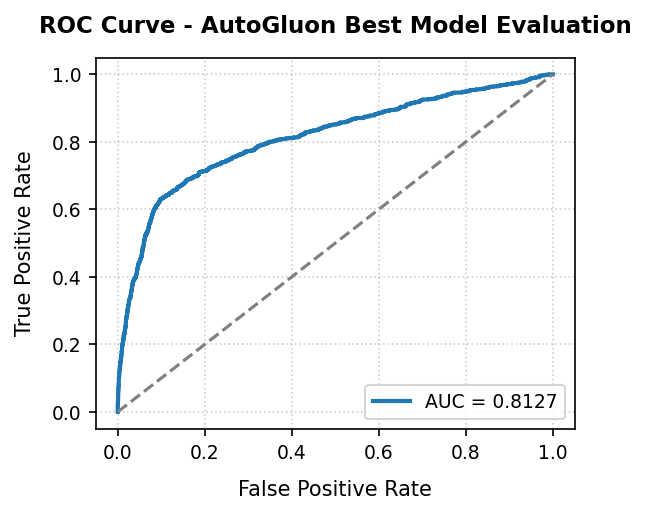

In [23]:
# compute false positive rate, true positive rate,
# and area under the curve for AutoGluon

fpr, tpr, _ = roc_curve(
    y_test,
    proba_test
)

roc_auc = auc(
    fpr,
    tpr
)

plt.figure(figsize=(4, 3.5), dpi=150)

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"AUC = {roc_auc:.4f}"
)

# plot the standard diagonal random classifier baseline
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray",
    linewidth=1.5
)

plt.grid(
    True,
    linestyle=":",
    alpha=0.6
)

plt.xlabel(
    "False Positive Rate",
    fontsize=10,
    labelpad=8
)

plt.ylabel(
    "True Positive Rate",
    fontsize=10,
    labelpad=8
)

plt.title(
    "ROC Curve - AutoGluon Best Model Evaluation",
    fontsize=11,
    fontweight="bold",
    pad=12
)

plt.legend(
    loc="lower right",
    fontsize=9
)

plt.tight_layout()

# save plot
plt.savefig(
    os.path.join(
        PLOT_DIR,
        "roc_curve_autogluon.png"
    ),
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close()

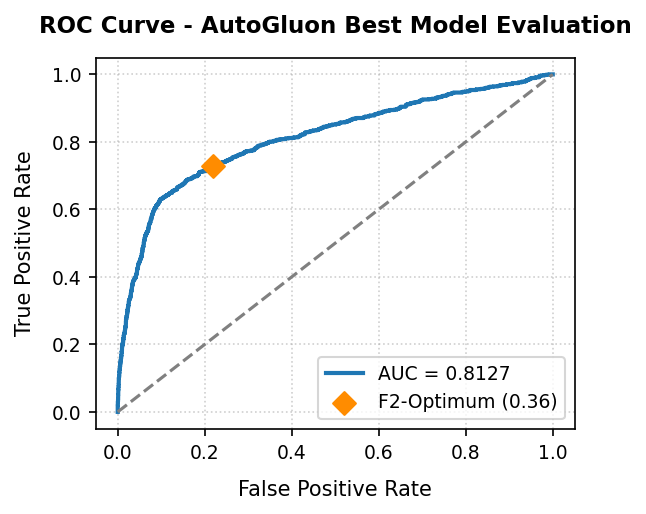

In [24]:
# Calculate the continuous roc curve and auc area

fpr, tpr, thresholds_roc = roc_curve(
    y_test,
    proba_test
)

roc_auc = auc(
    fpr,
    tpr
)


# Compute the exact coordinates for the F2 operating point


# Predict hard classes using the optimized F2 threshold
y_test_pred_f2 = (proba_test >= best_threshold_f2).astype(int)

# Extract confusion matrix to calculate the rates mathematically
# cm = [[TN, FP], [FN, TP]]
tn, fp, fn, tp = confusion_matrix(y_test, y_test_pred_f2).ravel()

# Calculate specific operating point coordinates
f2_tpr = tp / (tp + fn)  # True Positive Rate (Recall)
f2_fpr = fp / (fp + tn)  # False Positive Rate


# 3. Initialize the roc curve

plt.figure(figsize=(4, 3.5), dpi=150)

# Plot the continuous performance curve
plt.plot(
    fpr,
    tpr,
    linewidth=2,
    color='#1f77b4',
    label=f"AUC = {roc_auc:.4f}"
)

# Plot the standard diagonal random classifier baseline
plt.plot([0,1],[0,1]
 ,
    linestyle="--",
    color="gray",
    linewidth=1.5
)


# the F2 operational marker point

# Place the marker point as a prominent diamond on top of the curve
plt.scatter(
    f2_fpr,
    f2_tpr,
    color='darkorange',
    s=60,
    marker='D',
    zorder=5,
    label=f"F2-Optimum ({best_threshold_f2:.2f})"
)



plt.grid(
    True,
    linestyle=":",
    alpha=0.6
)

plt.xlabel(
    "False Positive Rate",
    fontsize=10,
    labelpad=8
)

plt.ylabel(
    "True Positive Rate",
    fontsize=10,
    labelpad=8
)

plt.title(
    "ROC Curve - AutoGluon Best Model Evaluation",
    fontsize=11,
    fontweight="bold",
    pad=12
)


plt.legend(
    loc="lower right",
    fontsize=9
)

plt.tight_layout()


plt.savefig(
    os.path.join(PLOT_DIR, "roc_curve_autogluon.png"),
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close()


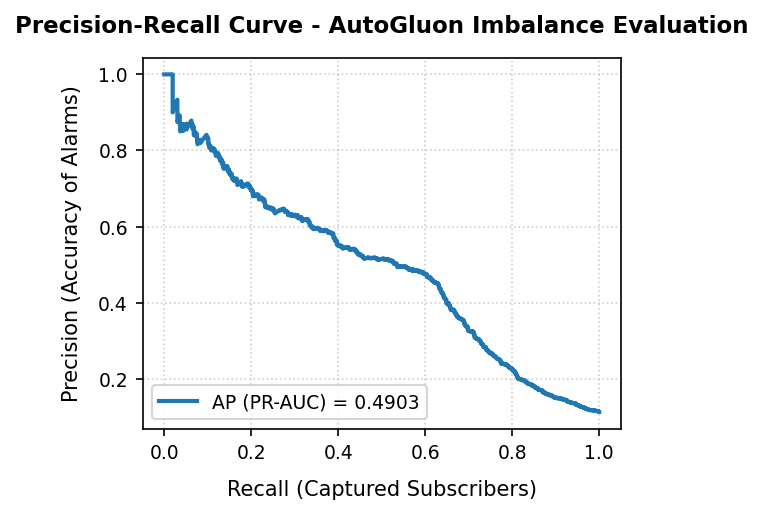

In [25]:
# compute precision, recall arrays and the average precision score
# for AutoGluon

precision_vals, recall_vals, _ = precision_recall_curve(
    y_test,
    proba_test
)

ap_score = average_precision_score(
    y_test,
    proba_test
)

# initialize the plot
plt.figure(figsize=(4, 3.5), dpi=150)

plt.plot(
    recall_vals,
    precision_vals,
    linewidth=2,
    label=f"AP (PR-AUC) = {ap_score:.4f}"
)

plt.grid(
    True,
    linestyle=":",
    alpha=0.6
)

plt.xlabel(
    "Recall (Captured Subscribers)",
    fontsize=10,
    labelpad=8
)

plt.ylabel(
    "Precision (Accuracy of Alarms)",
    fontsize=10,
    labelpad=8
)

plt.title(
    "Precision-Recall Curve - AutoGluon Imbalance Evaluation",
    fontsize=11,
    fontweight="bold",
    pad=12
)

plt.legend(
    loc="lower left",
    fontsize=9
)

plt.tight_layout()

# save plot
plt.savefig(
    os.path.join(
        PLOT_DIR,
        "precision_recall_curve_autogluon.png"
    ),
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close()

In [26]:
val_metrics = predictor.evaluate(
    val,
    model=best_model_final
)

test_metrics = predictor.evaluate(
    test,
    model=best_model_final
)

pr_auc_val = val_metrics["average_precision"]
pr_auc_test = test_metrics["average_precision"]

roc_auc_val = val_metrics["roc_auc"]
roc_auc_test = test_metrics["roc_auc"]

recall_val = val_metrics["recall"]
recall_test = test_metrics["recall"]

print("global model metrics (independent of classification thresholds):")
print("=" * 60)
print(f"validation pr-auc (focus on class 1): {pr_auc_val:.4f}")
print(f"test       pr-auc (focus on class 1): {pr_auc_test:.4f}")
print("-" * 60)
print(f"validation roc-auc (standard metric): {roc_auc_val:.4f}")
print(f"test       roc-auc (standard metric): {roc_auc_test:.4f}")
print("-" * 60)
print(f"validation recall  (true positive rate): {recall_val:.4f}")
print(f"test       recall  (true positive rate): {recall_test:.4f}")
print("=" * 60)

global model metrics (independent of classification thresholds):
validation pr-auc (focus on class 1): 0.6603
test       pr-auc (focus on class 1): 0.4903
------------------------------------------------------------
validation roc-auc (standard metric): 0.9111
test       roc-auc (standard metric): 0.8127
------------------------------------------------------------
validation recall  (true positive rate): 0.6724
test       recall  (true positive rate): 0.6390


In [27]:
print(f"saved operational outputs: {OUT_DIR}")
print(f"saved visualization outputs: {PLOT_DIR}")

print("-" * 60)
print(f"test roc-auc (global ranking quality):    {roc_auc_test:.4f}")
print(f"test pr-auc  (positive-class precision):  {pr_auc_test:.4f}")
print("=" * 60)
print(f"Final test F2-score (Threshold {best_threshold_f2:.2f}):  {f2_sota:.4f}")
print("-" * 60)
print("Business metrics for the campaign:")
print(f"-> Campaign recall (hit rate):        {rec_f2 * 100:.1f}%")
print(f"-> Campaign precision (efficiency):   {prec_f2 * 100:.1f}%")
print("=" * 60)

saved operational outputs: /content/autogluon_marketing_level1_outputs
saved visualization outputs: /content/autogluon_marketing_level1_outputs/plots
------------------------------------------------------------
test roc-auc (global ranking quality):    0.8127
test pr-auc  (positive-class precision):  0.4903
Final test F2-score (Threshold 0.36):  0.5642
------------------------------------------------------------
Business metrics for the campaign:
-> Campaign recall (hit rate):        72.7%
-> Campaign precision (efficiency):   29.7%


In [28]:
# Export predictions for cross-model comparison

comparison_export = pd.DataFrame({
    "y_true": y_test,
    "y_proba": proba_test
})

comparison_export.to_csv(
    "comparison_predictions_autogluon_l1.csv",
    index=False
)

print("Saved: comparison_predictions_autogluon_l1.csv")

Saved: comparison_predictions_autogluon_l1.csv
